# 01 · Data Cleaning
### The Outliers · Mumbai Rent Radar

**The question we are here to answer:** *what should a Mumbai flat actually cost to rent?*
The same 2BHK is listed at wildly different prices across localities, floors and furnishing.
Before any model can learn a fair price, the raw listings have to be made trustworthy.

This notebook takes the raw listings exactly as scraped and turns them into a clean table.
Every decision is written down next to the code, so anyone can see **what was wrong,
what we did, and what still stays imperfect.**

**Inputs:** `data/raw/Rental_Data.xlsx`, `data/raw/Attributes.csv`
**Output:** `data/processed/listings_clean.csv`, `data/processed/locality_attributes.csv`

In [1]:
import sys, re, warnings
sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import style
warnings.filterwarnings("ignore")
style.setup()

RAW = "../data/raw"
OUT = "../data/processed"
import os; os.makedirs(OUT, exist_ok=True)

raw = pd.read_excel(f"{RAW}/Rental_Data.xlsx", sheet_name="Rental Listings")
print("Raw listings:", raw.shape)
raw.head(4)

Raw listings: (5100, 12)


,Listing Id,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,LST101200,3,"₹147,500",1053.0,3 out of 3,Super Area,Dadar East,Mumbai,Semi Furnished,Family,3.0,Contact Agent
1,LST100250,1,"₹40,000",390.0,4 out of 12,Carpet Area,Parel,Mumbai,Unfurnished,Bachelors/Family,1.0,Contact Agent
2,LST101774,1,9500,562.0,7 out of 9,Super Area,"Green Gate Apartment, Pali Hill",Mumbai,Unfurnished,Bachelors/Family,1.0,Contact Agent
3,LST104358,2,15000,612.0,33 out of 41,Super Area,"Ajmera Treon, Bhakti Park",Mumbai,Semi-Furnished,Family,2.0,Contact Agent


## 1 · First look — where is the data missing?

`missingno` gives us an instant X-ray of gaps. White stripes = missing cells.
We read it before touching anything, so we know the size of the problem up front.

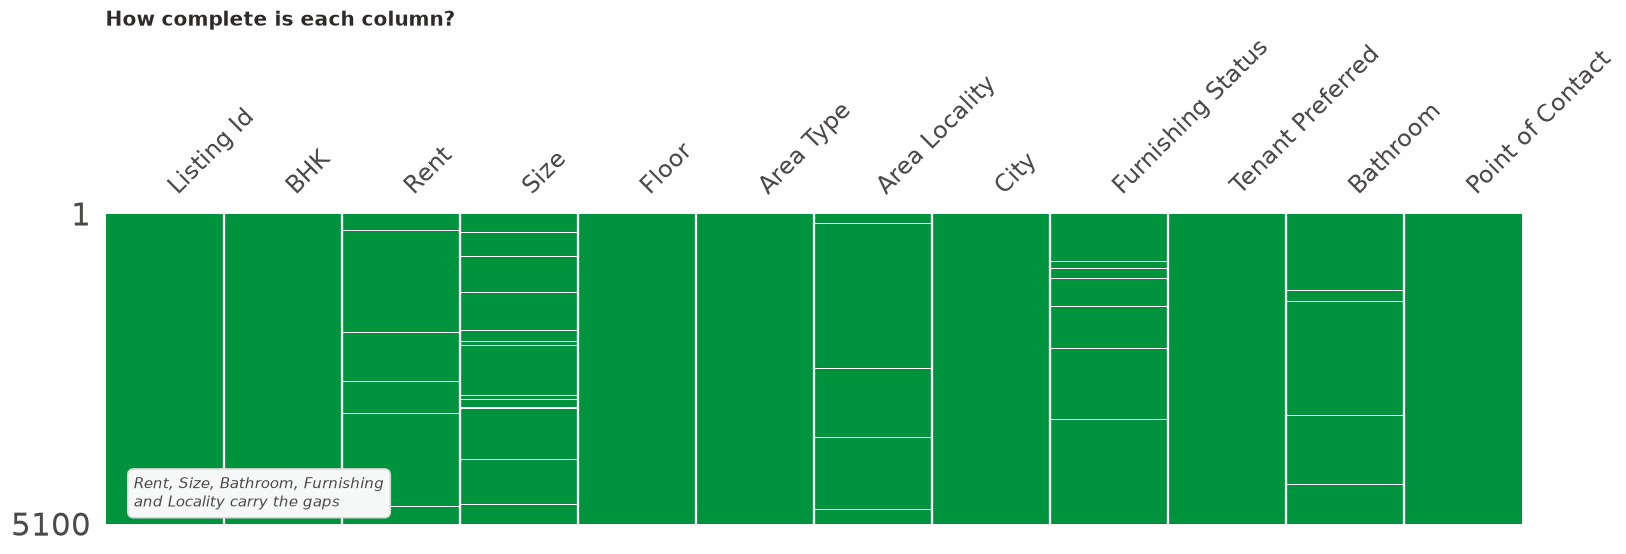

In [2]:
fig, ax = plt.subplots(figsize=(15, 5.2))
msno.matrix(raw, ax=ax, color=(0.0, 0.58, 0.24), sparkline=False)
ax.set_title("Missing-value map (each white gap = a blank cell)",
                  loc="left", fontweight="bold", color=style.INK, fontsize=13)
# msno.bar(raw, ax=axes[1], color=style.BLUE)
ax.set_title("How complete is each column?", loc="left",
                  fontweight="bold", color=style.INK, fontsize=13)
style.note(ax, "Rent, Size, Bathroom, Furnishing\nand Locality carry the gaps",
           where="lower left")
fig.tight_layout()
style.save(fig, "01_missingno")
plt.show()

In [3]:
miss = raw.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
print("Columns with missing values:")
print(miss.to_string())

Columns with missing values:
Size                 237
Bathroom              85
Area Locality         62
Furnishing Status     53
Rent                  51
Floor                 11


## 2 · The mess, before we fix it

The raw file has the *same thing spelled many ways*. That silently splinters every
grouping and blocks the join to locality attributes. A quick census of the damage:

In [4]:
for col in ["City", "Area Type", "Furnishing Status", "Tenant Preferred", "Point of Contact"]:
    vals = sorted(raw[col].dropna().unique().tolist())
    print(f"{col:20} {len(vals)} spellings ->", vals)
print("\nRent stored as text, e.g.:", raw['Rent'].dropna().astype(str).unique()[:6].tolist())
print("Floor stored as text, e.g.:", raw['Floor'].dropna().astype(str).unique()[:5].tolist())

City                 6 spellings -> [' Mumbai', 'Bombay', 'MUMBAI', 'Mumbai', 'Mumbai ', 'mumbai']
Area Type            7 spellings -> ['Built Up Area', 'Carpet  Area', 'Carpet Area', 'Super  Area', 'Super Area', 'carpet area', 'super area']
Furnishing Status    8 spellings -> ['Fully Furnished', 'Furnished', 'Semi Furnished', 'Semi-Furnished', 'Unfurnishd', 'Unfurnished', 'furnished', 'semi-furnished']
Tenant Preferred     7 spellings -> ['Bachelors', 'Bachelors ', 'Bachelors / Family', 'Bachelors/Family', 'Family', 'Family ', 'bachelors/family']
Point of Contact     6 spellings -> ['Agent', 'Contact  Agent', 'Contact Agent', 'Contact Owner', 'Owner', 'contact owner']

Rent stored as text, e.g.: ['₹147,500', '₹40,000', '9500', '15000', '31500', '189500']
Floor stored as text, e.g.: ['3 out of 3', '4 out of 12', '7 out of 9', '33 out of 41', '32 out of 46']


**Decision log — the fixes we apply below and why:**

| Field | Problem | Fix | Why |
|---|---|---|---|
| `City` | Bombay / mumbai / MUMBAI / spaces | collapse to **Mumbai** | one city only; noise, not signal |
| `Rent` | `₹147,500`, `40,000`, `50k`, `/-` | strip symbols, expand `k`→×1000 → number | a price must be numeric to model |
| `Area Type` | `Super  Area` vs `super area` | trim + Title Case → 3 clean types | same category, different casing |
| `Furnishing` | `Semi Furnished`/`Semi-Furnished`, `Unfurnishd` | map to 3 clean labels | typos split real groups |
| `Tenant`, `Contact` | slashes & spacing | canonical labels | same as above |
| `Floor` | `7 out of 9`, `Ground`, `Upper Basement` | split into **floor number** + **building height** | two useful numbers hide in one string |
| `Bathroom = 0` | impossible | set to missing | a flat has ≥1 bathroom |
| `Size < 100 sqft` | impossible for a whole flat | set to missing | typo, not a real home |
| `Area Locality` | building + area mixed together | split into **address** + **locality_name** | the locality is the join key & price driver |
| duplicates | repeated listing IDs | drop | double-counting biases everything |

In [5]:
df = raw.copy()

# --- City: every variant is Mumbai ---
df["city"] = "Mumbai"

# --- Rent: text -> number (handles ₹, commas, /-, and the 'k' shorthand) ---
def parse_rent(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower().replace("₹", "").replace(",", "").replace("/-", "").replace(" ", "")
    if s in ("", "-", "na", "nan"): return np.nan
    mult = 1000.0 if s.endswith("k") else 1.0
    if s.endswith("k"): s = s[:-1]
    try: return float(s) * mult
    except: return np.nan
df["rent"] = df["Rent"].map(parse_rent)

# --- helper to squeeze internal whitespace ---
collapse = lambda s: re.sub(r"\s+", " ", str(s).strip())

# --- Area type ---
df["area_type"] = df["Area Type"].map(lambda s: collapse(s).title() if pd.notna(s) else np.nan)

# --- Furnishing ---
def furn(s):
    if pd.isna(s): return np.nan
    t = collapse(s).lower()
    return ("Unfurnished" if "unfurnish" in t else
            "Semi-Furnished" if "semi" in t else
            "Furnished" if "furnish" in t else np.nan)
df["furnishing_status"] = df["Furnishing Status"].map(furn)

# --- Tenant preferred ---
def tenant(s):
    if pd.isna(s): return np.nan
    t = collapse(s).lower().replace(" / ", "/").replace(" /", "/").replace("/ ", "/")
    if "bachelor" in t and "family" in t: return "Bachelors/Family"
    if "bachelor" in t: return "Bachelors"
    if "family" in t: return "Family"
    return np.nan
df["tenant_preferred"] = df["Tenant Preferred"].map(tenant)

# --- Point of contact ---
def poc(s):
    if pd.isna(s): return np.nan
    t = collapse(s).lower()
    return "Contact Owner" if "owner" in t else "Contact Agent" if "agent" in t else np.nan
df["point_of_contact"] = df["Point of Contact"].map(poc)

# --- Floor: one string -> floor number + building height ---
def parse_floor(x):
    if pd.isna(x): return (np.nan, np.nan)
    s = str(x).strip().lower()
    if s in ("unknown", "not available", "-", "", "na"): return (np.nan, np.nan)
    m = re.search(r"out of\s+(\d+)", s)
    total = float(m.group(1)) if m else np.nan
    head = re.split(r"out of", s)[0].strip()
    if "lower basement" in head: fn = -2.0
    elif "upper basement" in head or head == "basement": fn = -1.0
    elif "ground" in head: fn = 0.0
    else:
        mm = re.search(r"-?\d+", head); fn = float(mm.group()) if mm else np.nan
    return (fn, total)
fl = df["Floor"].map(parse_floor)
df["floor_num"] = [a for a, _ in fl]
df["total_floors"] = [b for _, b in fl]

# --- Impossible values -> missing (imputed in the next notebook) ---
df["bhk"] = df["BHK"]
df["bathroom"] = df["Bathroom"].replace(0, np.nan)
df["size"] = df["Size"].where(df["Size"] >= 100, np.nan)

# --- Locality: building + area -> address + locality_name (join key) ---
def split_locality(x):
    if pd.isna(x): return (np.nan, np.nan)
    addr = collapse(x)
    parts = [p.strip() for p in addr.split(",") if p.strip()]
    parts = [p for p in parts if "mumbai" not in p.lower()]   # drop the city token
    return (addr, parts[-1] if parts else np.nan)             # keep the area as the key
sp = df["Area Locality"].map(split_locality)
df["address"] = [a for a, _ in sp]
df["locality_name"] = [b for _, b in sp]

impossible_bath = int((raw["Bathroom"] == 0).sum())
impossible_size = int((raw["Size"] < 100).sum())
print(f"Impossible values set to missing -> bathroom=0: {impossible_bath} rows | size<100sqft: {impossible_size} rows")

Impossible values set to missing -> bathroom=0: 3 rows | size<100sqft: 5 rows


## 3 · Remove duplicates
Exact repeats and repeated listing IDs both double-count the same flat.

In [6]:
n0 = len(df)
df = df.drop_duplicates()
n1 = len(df)
df = df.drop_duplicates(subset=["Listing Id"], keep="first")
n2 = len(df)
print(f"Rows: {n0} -> drop exact repeats -> {n1} -> drop repeated IDs -> {n2}")
print(f"Removed {n0 - n2} duplicate rows ({(n0 - n2) / n0 * 100:.1f}% of the file)")

Rows: 5100 -> drop exact repeats -> 5073 -> drop repeated IDs -> 5050
Removed 50 duplicate rows (1.0% of the file)


## 4 · Before → after: did the cleaning actually help?

**Chart A** counts how many distinct spellings each field had before vs after.
Fewer bars after = the same real categories, no longer splintered.

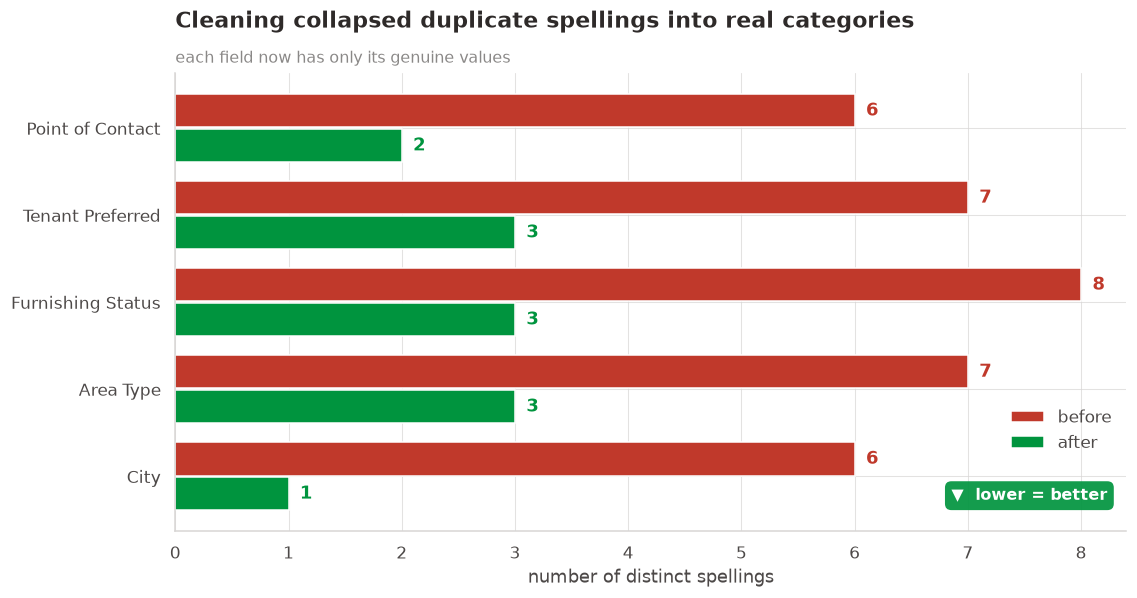

In [7]:
messy_cols = {"City": "city", "Area Type": "area_type", "Furnishing Status": "furnishing_status",
              "Tenant Preferred": "tenant_preferred", "Point of Contact": "point_of_contact"}
before = [raw[o].nunique() for o in messy_cols]
after = [df[n].nunique() for n in messy_cols.values()]
labels = list(messy_cols.keys())

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y = np.arange(len(labels))
ax.barh(y + 0.2, before, height=0.38, color=style.BAD, label="before")
ax.barh(y - 0.2, after, height=0.38, color=style.GOOD, label="after")
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(b + 0.1, i + 0.2, str(b), va="center", color=style.BAD, fontweight="bold")
    ax.text(a + 0.1, i - 0.2, str(a), va="center", color=style.GOOD, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("number of distinct spellings")
style.title(ax, "Cleaning collapsed duplicate spellings into real categories",
            "each field now has only its genuine values")
style.direction_badge(ax, "lower", "lower right")
ax.legend(loc="lower right", bbox_to_anchor=(1, 0.14))
fig.tight_layout()
style.save(fig, "01_before_after_categories")
plt.show()

**Insight:** every messy field collapsed to its true number of categories
(City 6→1, Area Type 7→3, Furnishing 8→3, Tenant 7→3, Contact 6→2).
**Decision:** these canonical labels become the modelling categories downstream.

**Chart B** shows the payoff on Rent: thousands of prices were trapped as text
in four different formats. Parsing recovered almost all of them into one number.

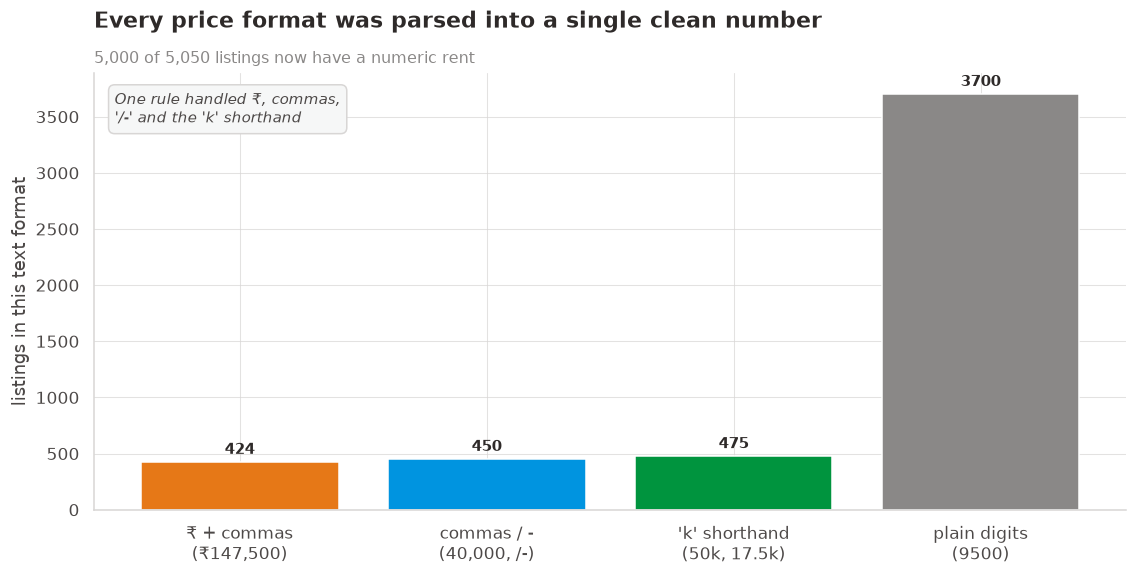

In [8]:
r = raw["Rent"].dropna().astype(str)
fmt = pd.Series({
    "₹ + commas\n(₹147,500)": r.str.contains("₹").sum(),
    "commas / -\n(40,000, /-)": (r.str.contains(",") & ~r.str.contains("₹")).sum() + r.str.contains("/-").sum(),
    "'k' shorthand\n(50k, 17.5k)": r.str.contains("k", case=False).sum(),
    "plain digits\n(9500)": r.str.match(r"^\d+$").sum(),
})
recovered = df["rent"].notna().sum()
total = raw["rent"] if "rent" in raw else df["rent"]

fig, ax = plt.subplots(figsize=(10.5, 5.4))
bars = ax.bar(fmt.index, fmt.values, color=[style.ORANGE, style.BLUE, style.GREEN, style.GREY])
style.bar_labels(ax, fmt="{:.0f}")
style.title(ax, "Every price format was parsed into a single clean number",
            f"{recovered:,} of {len(df):,} listings now have a numeric rent")
style.note(ax, "One rule handled ₹, commas,\n'/-' and the 'k' shorthand", where="upper left")
ax.set_ylabel("listings in this text format")
fig.tight_layout()
style.save(fig, "01_rent_formats")
plt.show()

**Insight:** the "50k" shorthand alone hid ~475 prices that would otherwise have
been dropped as missing. **Decision:** keep the `k`-expansion rule — it recovers real data.

## 5 · Prepare the locality attributes table (the join key)
The attributes table describes each locality (metro access, tech-park distance, schools…).
We give it the **same** `locality_name` key and keep one row per locality so it can be
joined cleanly during feature engineering.

In [9]:
att = pd.read_csv(f"{RAW}/Attributes.csv")
spa = att["locality_name"].map(split_locality)
att["address"] = [a for a, _ in spa]
att["locality_name"] = [b for _, b in spa]
att = att.dropna(subset=["locality_name"]).drop_duplicates(subset=["locality_name"], keep="first")

rl = set(df["locality_name"].dropna().str.lower())
al = set(att["locality_name"].str.lower())
matched = df["locality_name"].str.lower().isin(al).sum()
print(f"Locality attributes: {len(att)} unique localities")
print(f"Listings that will find their locality: {matched:,}/{len(df):,} = {matched/len(df)*100:.1f}%")

Locality attributes: 267 unique localities
Listings that will find their locality: 4,966/5,050 = 98.3%


## 6 · Save the clean tables

In [10]:
keep = ["Listing Id", "city", "locality_name", "address", "bhk", "rent", "size",
        "area_type", "floor_num", "total_floors", "bathroom", "furnishing_status",
        "tenant_preferred", "point_of_contact"]
clean = df[keep].rename(columns={"Listing Id": "listing_id"}).reset_index(drop=True)
clean.to_csv(f"{OUT}/listings_clean.csv", index=False)
att.to_csv(f"{OUT}/locality_attributes.csv", index=False)
print("Saved listings_clean.csv", clean.shape, "and locality_attributes.csv", att.shape)
clean.head(4)

Saved listings_clean.csv (5050, 14) and locality_attributes.csv (267, 38)


,listing_id,city,locality_name,address,bhk,rent,size,area_type,floor_num,total_floors,bathroom,furnishing_status,tenant_preferred,point_of_contact
0,LST101200,Mumbai,Dadar East,Dadar East,3,147500.0,1053.0,Super Area,3.0,3.0,3.0,Semi-Furnished,Family,Contact Agent
1,LST100250,Mumbai,Parel,Parel,1,40000.0,390.0,Carpet Area,4.0,12.0,1.0,Unfurnished,Bachelors/Family,Contact Agent
2,LST101774,Mumbai,Pali Hill,"Green Gate Apartment, Pali Hill",1,9500.0,562.0,Super Area,7.0,9.0,1.0,Unfurnished,Bachelors/Family,Contact Agent
3,LST104358,Mumbai,Bhakti Park,"Ajmera Treon, Bhakti Park",2,15000.0,612.0,Super Area,33.0,41.0,2.0,Semi-Furnished,Family,Contact Agent


## 7 · What we cleaned, at a glance

- **Duplicates:** 50 repeated listings removed.
- **Impossible values:** 0-bathroom and sub-100-sqft entries set to missing for honest imputation.
- **Standardised text:** 6 fields collapsed from dozens of spellings to their true categories.
- **Two numbers unlocked** from the `Floor` string; **the locality key** unlocked from the address.
- **Still imperfect (carried forward):** genuine gaps in rent, size, bathroom and furnishing
  remain — the next notebook imputes them, honestly and visibly.

→ Full write-up in `docs/data_quality_note.md`.